In [42]:
from matplotlib import pyplot as plt 
from pathlib import Path

import pandas as pd

import numpy as np

In [5]:
ARTIFACT_DIR = Path("../../artifacts/2023-05-S5/experiment-imagenet-auroc")

In [76]:
df_imagenet_class_mapping = pd.read_csv("https://raw.githubusercontent.com/p16i/concept-xai/dev/cxai/config/imagenet-label-mapping.csv?token=GHSAT0AAAAAACAALDUND6GKOXUCPJCKTM3QZCY6ZEA")

In [82]:
def desc(ix):
    
    return df_imagenet_class_mapping.desc[ix]


def label(ix):
    
    return f"{desc(ix)} ({ix})"

desc(323), label(323)

('monarch', 'monarch (323)')

In [9]:
def load_data(model_name, main_class):
    
    df = pd.read_csv(ARTIFACT_DIR / f"auroc-{model_name}-{main_class}.csv")
    
    return df


load_data("imagenet-resnet18-tv", 322)

,model,count,classes,auroc_corrreted,auroc
0,imagenet-resnet18-tv,100,322vs323,1.0000,0.0000
1,imagenet-resnet18-tv,100,322vs324,0.9976,0.0024
2,imagenet-resnet18-tv,100,322vs325,0.9988,0.0012
3,imagenet-resnet18-tv,100,322vs326,0.9912,0.0088
4,imagenet-resnet18-tv,100,322vs388,1.0000,0.0000
5,imagenet-resnet18-tv,100,322vs555,1.0000,0.0000
6,imagenet-resnet18-tv,100,322vs732,1.0000,0.0000
7,imagenet-resnet18-tv,100,322vs999,1.0000,0.0000


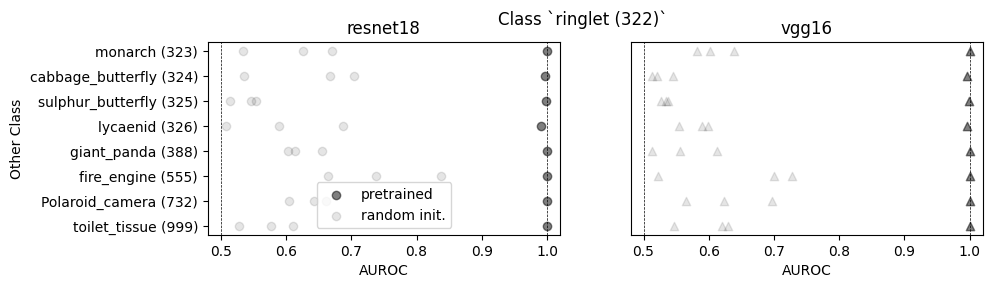

In [95]:
def marker(model_name):
    
    if "resnet18" in model_name:
        return "o"
    elif "vgg16" in model_name:
        return "^"
    else:
        raise
        
def viz(
    main_class,
    archs=["resnet18", "vgg16"],
    variants=[
        "tv",
        "random1",
        "random2",
        "random3",
    ]):
    
    
    
    ncols = len(archs)
    
    plt.figure(figsize=(5*ncols, 2.5))
    plt.suptitle(f"Class `{label(main_class)}`", y=1.01)
    for aix, arch in enumerate(archs):
        plt.subplot(1, ncols, aix+1)
        
        plt.axvline(0.5, ls="--", lw=0.5, color="k")
        plt.axvline(1, ls="--", lw=0.5, color="k")
    
        for variant in variants:
            
            df = load_data(f"imagenet-{arch}-{variant}", main_class)
        
            params = dict(
                marker=marker(arch),
                color="k",
                alpha= 0.1 if "random" in variant else 0.5,
            )
            if variant == "tv": 
                params["label"] = "pretrained"
            elif variant == "random1":
                params["label"] = "random init."

                
                
            ticks = np.arange(df.shape[0])[::-1]
            plt.title(arch)
            plt.scatter(
                df["auroc_corrreted"],
                ticks,
                **params
            )
        
        
        
        plt.xlim([0.48, 1.02])

        if aix == 0:
            plt.yticks(ticks, map(lambda s: label(int(s.split("vs")[-1])), df["classes"].values))
            plt.ylabel("Other Class")
            plt.legend()
        else:
            plt.yticks([])

        
        plt.xlabel(f"AUROC")
    
viz(322)

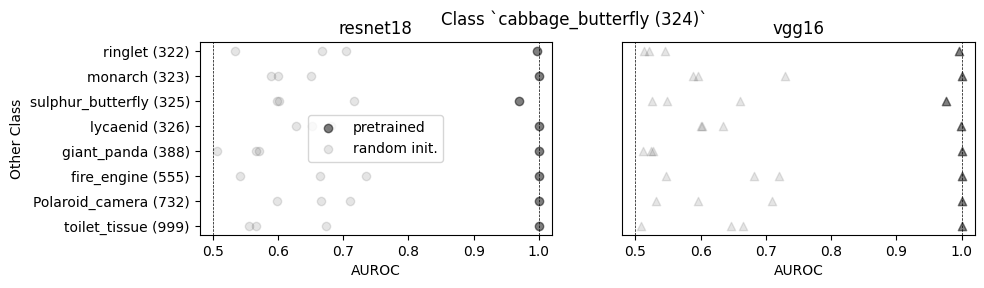

In [98]:
viz(324)

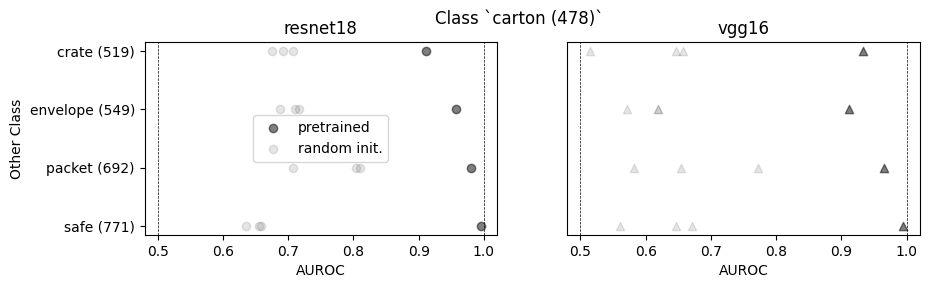

In [97]:
viz(478)

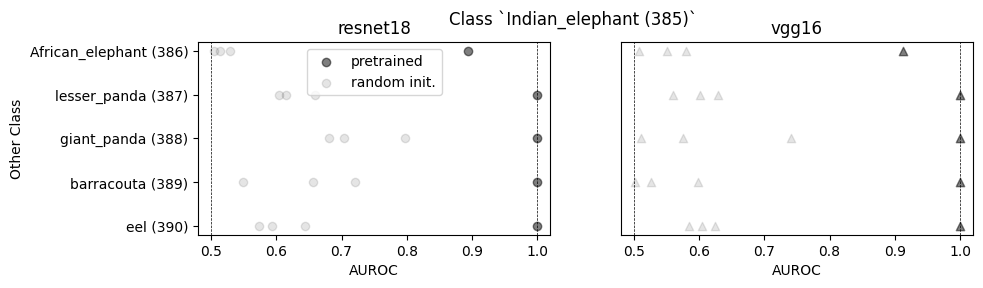

In [100]:
viz(385)